In [1]:
import sys
!{sys.executable} -m pip install -q yfinance pandas-datareader scikit-learn xlsxwriter matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 2.6 MB/s eta 0:00:00


In [2]:
import sys
!{sys.executable} -m pip install -q imblearn

In [3]:
# (Import SMOTE residuel du pipeline supervise original - non utilise dans ce
# notebook exploratoire purement non supervise. Neutralise.)


In [4]:
import os
import re
import time
import json
import warnings
from pathlib import Path
from typing import Dict, List
from collections import defaultdict
from itertools import combinations

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader as pdr
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA


# =============================================================================
# CONFIG
# =============================================================================
#
# OBJECTIF DE CE NOTEBOOK : EXPLORATOIRE UNIQUEMENT, AUCUN ENTRAINEMENT
# SUPERVISE.
#
# Teste si un clustering non supervisé (K-Means et Gaussian Mixture Model)
# sur un large ensemble de features macro/marché révèle des régimes de
# marché différents de la segmentation CALM/NORMAL/STRESS actuelle (basée
# uniquement sur des quantiles du niveau de VIX).
#
# Démarche non supervisée stricte : la sélection de features se fait par
# variance + filtrage d'inter-corrélation, SANS utiliser VIX_Direction (la
# cible du pipeline supervisé) à aucun moment. Le nombre de clusters n'est
# pas présupposé à 3 - il est déterminé par la méthode du coude (inertie
# K-Means) et le score de silhouette.
#
# Aucun modèle prédictif n'est entraîné ici. C'est un notebook de
# familiarisation / diagnostic, pas une étape du pipeline de prédiction.

OUTPUT_DIR = Path("/content/outputs_v21_regime_clustering_exploration")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

MIN_DATA_START = pd.Timestamp("2000-01-01")
TRAIN_START = "2000-01-01"

FEATURE_PREFILTER_TOP_N = 300

YF_CHUNK_SIZE = 40
SLEEP_BETWEEN_CHUNKS = 1.0

MIN_COLUMN_COVERAGE = 0.90
MAX_FIRST_VALID_LAG_DAYS = 365

# --- Sélection de features NON SUPERVISÉE (pas de cible utilisée) ---
N_TOP_VARIANCE_FEATURES = 60          # pré-filtre large par variance
N_FINAL_CLUSTERING_FEATURES = 20      # nombre final retenu après filtre inter-corrélation
INTER_FEATURE_CORR_THRESHOLD = 0.85   # au-delà, on élimine la feature redondante

# --- Clustering ---
K_RANGE_TO_TEST = range(2, 9)         # nombre de clusters testés (2 à 8)

np.random.seed(RANDOM_STATE)

FRED_API_KEY = os.getenv("FRED_API_KEY")
if FRED_API_KEY:
    os.environ["FRED_API_KEY"] = FRED_API_KEY


In [5]:
# (Cellule du pipeline supervisé original, non utilisée dans ce notebook
# exploratoire purement non supervisé - neutralisée.)


In [6]:
# (Cellule du pipeline supervisé original, non utilisée dans ce notebook
# exploratoire purement non supervisé - neutralisée.)


In [7]:
# (Cellule du pipeline supervisé original, non utilisée dans ce notebook
# exploratoire purement non supervisé - neutralisée.)


In [8]:
BAD_TICKERS = {
    "XXIV",
    "TVIX",
    "ZIV",
    "^MIB",
    "CELG",
    "AET",
    "HES",
    "GPS",
    "JWN",
    "DFS",
    "SPX",
    "EON",
    "EDF",
    "RWE",
    "SZR",
    "ICN",
    "CEIX",
    "MXEA",
    "SQ",
    "SHELL",
    "K",
}

MANUAL_YF_NAMES = {
    "^GSPC": "SP500_Price",
    "^IXIC": "NASDAQ_Price",
    "^DJI": "DOW_Price",
    "^RUT": "Russell_Price",
    "^VIX": "VIX_Price",
    "^VXN": "VXN_NASDAQ_Vol",
    "^OVX": "OVX_Oil_Vol",
    "^GVZ": "GVZ_Gold_Vol",
    "^EVZ": "EVZ_EUR_Vol",
    "^FTSE": "FTSE_UK",
    "^N225": "Nikkei_Japan",
    "^HSI": "HangSeng_HK",
    "^GDAXI": "DAX_Germany",
    "^FCHI": "CAC40_France",
    "^STOXX50E": "STOXX50E_EU",
    "SPY": "SPY",
    "QQQ": "QQQ",
    "TLT": "TLT_LongBond",
    "GLD": "GLD_Gold",
    "USO": "USO_Oil",
    "UUP": "UUP_Dollar",
    "FXE": "FXE_Euro",
    "FXY": "FXY_Yen",
    "HYG": "HYG_HighYield",
    "LQD": "LQD_InvGrade",

    # --- Tickers ajoutés (issus du dictionnaire massif fourni) ---
    "^BVSP": "BOVESPA_Brazil",
    "^AXJO": "ASX_Australia",
    "^AORD": "AORD_AUS",
    "^IBEX": "IBEX_Spain",
    "VXX": "VXX",
    "UVXY": "UVXY",
    "VIXY": "VIXY",
    "SVXY": "SVXY",
    "VXZ": "VXZ",
    "VIXM": "VIXM",
    "XLK": "XLK_Tech",
    "XLF": "XLF_Fin",
    "XLE": "XLE_Energy",
    "XLV": "XLV_Health",
    "XLU": "XLU_Util",
    "XLP": "XLP_Staples",
    "XLI": "XLI_Indust",
    "XLY": "XLY_Disc",
    "XLRE": "XLRE_RE",
    "XLB": "XLB_Materials",
    "XLC": "XLC_CommServ",
    "GOOGL": "GOOGL_Google",
    "META": "META_Meta",
    "AVGO": "AVGO_Broadcom",
    "ASML": "ASML_ASML",
    "WFC": "WFC_WellsFargo",
    "GS": "GS_GoldmanSachs",
    "BLK": "BLK_BlackRock",
    "SCHW": "SCHW_Schwab",
    "MS": "MS_MorganStanley",
    "COF": "COF_CapitalOne",
    "BAX": "BAX_BankBoston",
    "AXP": "AXP_Amex",
    "EQR": "EQR_Equity",
    "PLD": "PLD_Prologis",
    "AMT": "AMT_AmericanTower",
    "EQIX": "EQIX_Equinix",
    "CCI": "CCI_CrownCastle",
    "PSA": "PSA_PublicStorage",
    "ABBV": "ABBV_AbbVie",
    "MRK": "MRK_Merck",
    "BMY": "BMY_BristolMyers",
    "AMGN": "AMGN_Amgen",
    "GILD": "GILD_Gilead",
    "BNTX": "BNTX_BioNTech",
    "MRNA": "MRNA_Moderna",
    "CRSP": "CRSP_CrisprTherapy",
    "VRTX": "VRTX_VertexPharm",
    "ILMN": "ILMN_Illumina",
    "DXCM": "DXCM_Dexcom",
    "TDOC": "TDOC_Teladoc",
    "CI": "CI_Cigna",
    "HUM": "HUM_Humana",
    "RTX": "RTX_Raytheon",
    "LMT": "LMT_LockheedMartin",
    "NOC": "NOC_Northrop",
    "GD": "GD_GeneralDynamics",
    "CAT": "CAT_Caterpillar",
    "DE": "DE_Deere",
    "ITT": "ITT_ITTInc",
    "PAYX": "PAYX_Paychex",
    "CTAS": "CTAS_Cintas",
    "MMM": "3M",
    "HON": "HON_Honeywell",
    "ETN": "ETN_Eaton",
    "EMR": "EMR_Emerson",
    "OTIS": "OTIS_Otis",
    "JCI": "JCI_JohnsonControls",
    "PTC": "PTC_PTC",
    "SMCI": "SMCI_SuperMicroComputer",
    "COP": "COP_ConocoPhillips",
    "SLB": "SLB_Schlumberger",
    "EOG": "EOG_EOGResources",
    "MPC": "MPC_MarathonPetroleum",
    "PSX": "PSX_PhillipsLiquids",
    "VLO": "VLO_Valero",
    "PM": "PM_PhilipMorris",
    "MO": "MO_AltriaMG",
    "BTI": "BTI_BritishAmerican",
    "TBP": "TBP_Tata",
    "BP": "BP_BritishPetroleum",
    "TTE": "TTE_TotalEnergies",
    "ENB": "ENB_EnbridgeInc",
    "MET": "MET_MetalexEnergy",
    "ADM": "ADM_ArcherDaniels",
    "MKC": "MKC_McCormick",
    "SJM": "SJM_JM_Smucker",
    "CPB": "CPB_CampbellSoup",
    "GIS": "GIS_GeneralMills",
    "MDLZ": "MDLZ_Mondelez",
    "NSRGY": "NSRGY_Nestle",
    "TAP": "TAP_MolsonCoors",
    "BDX": "BDX_Becton_Dickinson",
    "CLX": "CLX_Clorox",
    "CL": "CL_Colgate",
    "UL": "UL_Unilever",
    "LVRK": "LVRK_Lavazza",
    "YUM": "YUM_YumBrands",
    "QSR": "QSR_RestaurantBrands",
    "DPZ": "DPZ_Dominos",
    "BLMN": "BLMN_BloombergME",
    "NWL": "NWL_Newell",
    "RRR": "RRR_RareMedica",
    "DASH": "DASH_DoorDash",
    "LYFT": "LYFT_Lyft",
    "UBER": "UBER_Uber",
    "TGT": "TGT_Target",
    "M": "M_Macys",
    "LOW": "LOW_Lowes",
    "ROST": "ROST_RossStores",
    "BBY": "BBY_BestBuy",
    "NEE": "NEE_NextEra",
    "DUK": "DUK_Duke",
    "SO": "SO_SouthernCo",
    "AEP": "AEP_AmericanElectric",
    "EXC": "EXC_Exelon",
    "SRE": "SRE_Sempra",
    "ES": "ES_Evergy",
    "XEL": "XEL_Xcel",
    "PPL": "PPL_PPL",
    "TMUS": "TMUS_TMobileUS",
    "CHTR": "CHTR_Charter",
    "VOD": "VOD_Vodafone",
    "TM": "TM_Telephone",
    "LOGI": "LOGI_Logitech",
    "NET": "NET_Cloudflare",
    "DDOG": "DDOG_Datadog",
    "SLV": "SLV_Silver",
    "UNG": "UNG_Gas",
    "DBC": "DBC_Commodity",
    "DBA": "DBA_Agri",
    "GDX": "GDX_GoldMiners",
    "GDXJ": "GDXJ_JrMiners",
    "PDBC": "PDBC_Commodity2",
    "CORN": "CORN_Corn",
    "SOYB": "SOYB_Soybean",
    "CBOT_W": "Wheat",
    "IEF": "IEF_MidBond",
    "SHY": "SHY_ShortBond",
    "SHV": "SHV_TBill",
    "BIL": "BIL_TBill3M",
    "AGG": "AGG_Aggregate",
    "BND": "BND_TotalBond",
    "JNK": "JNK_HY2",
    "VCIT": "VCIT_CorpIG",
    "VCSH": "VCSH_CorpST",
    "EMB": "EMB_EM",
    "MBB": "MBB_Mortgage",
    "TIP": "TIP_TIPS",
    "BNDX": "BNDX_IntlBond",
    "HYLD": "HYLD_HYieldETF",
    "PFFA": "PFFA_PreferredA",
    "EWJ": "EWJ_Japan",
    "EWG": "EWG_Germany",
    "EWU": "EWU_UK",
    "EWA": "EWA_Australia",
    "EWH": "EWH_HongKong",
    "EWL": "EWL_Switzerland",
    "EWP": "EWP_Spain",
    "EWI": "EWI_Italy",
    "EWQ": "EWQ_France",
    "EWT": "EWT_Taiwan",
    "EWY": "EWY_Korea",
    "EWZ": "EWZ_Brazil",
    "EWC": "EWC_Canada",
    "EWS": "EWS_Singapore",
    "EWM": "EWM_Malaysia",
    "FXI": "FXI_China",
    "MCHI": "MCHI_China2",
    "IEMG": "IEMG_EM",
    "EEM": "EEM_EM2",
    "VEA": "VEA_DM",
    "INDA": "INDA_India",
    "EPI": "EPI_India2",
    "ASHR": "ASHR_China_A",
    "TUR": "TUR_Turkey",
    "EIDO": "EIDO_Indonesia",
    "EPOL": "EPOL_Poland",
    "EZA": "EZA_SouthAfrica",
    "GXG": "GXG_Germany2",
    "EGRX": "EGRX_Greece",
    "FXB": "FXB_GBP",
    "FXA": "FXA_AUD",
    "FXC": "FXC_CAD",
    "FXF": "FXF_CHF",
    "CEW": "CEW_EM_FX",
    "CYB": "CYB_ChineseYuan",
    "BZF": "BZF_BrazilReal",
    "FXD": "FXD_SwedishKrona",
    "FXN": "FXN_NorwegianKrone",
    "GBTC": "GBTC_Bitcoin",
    "IBIT": "IBIT_Bitcoin2",
    "COIN": "COIN_Crypto",
    "MSTR": "MSTR_Bitcoin3",
    "BITO": "BITO_BitcoinETF",
    "ETHA": "ETHA_EthereumETF",
    "MARA": "MARA_Marathon",
    "RIOT": "RIOT_Riot",
    "CLSK": "CLSK_CleanSpark",
    "CIFR": "CIFR_Cipher",
    "CORZ": "CORZ_Core_Sci",
    "IWM": "IWM_SmallCap",
    "IVV": "IVV_SP500",
    "VTI": "VTI_Total",
    "VOO": "VOO_SP500_2",
    "VV": "VV_LargeCap",
    "VTV": "VTV_Value",
    "VUG": "VUG_Growth",
    "VB": "VB_SmallCap2",
    "SCHD": "SCHD_Div",
    "VIG": "VIG_DivGrowth",
    "HDV": "HDV_HighDiv",
    "NOBL": "NOBL_Aristocrat",
    "DGRO": "DGRO_DividendGrowth",
    "QUAL": "QUAL_Quality",
    "VLUE": "VLUE_Value",
    "VYMI": "VYMI_HighDivYield",
    "JEPI": "JEPI_EquityPremiumIncome",
    "XYLD": "XYLD_XYieldETF",
    "QYLD": "QYLD_NasdaqYield",
    "RYLD": "RYLD_Russell2000Yield",
    "ARKK": "ARKK_Innovation",
    "XBI": "XBI_Biotech",
    "SOXX": "SOXX_Semis",
    "IBB": "IBB_Biotech2",
    "IYT": "IYT_Transport",
    "XHB": "XHB_Homebuilders",
    "KRE": "KRE_RegionalBanks",
    "KBE": "KBE_Banks",
    "ITA": "ITA_Defense",
    "XOP": "XOP_OilExploration",
    "OIH": "OIH_OilServices",
    "IYM": "IYM_BasicMaterials",
    "PCAR": "PCAR_PaccarInc",
    "DAL": "DAL_Delta",
    "AAL": "AAL_AmericanAir",
    "UAL": "UAL_UnitedAir",
    "LUV": "LUV_SouthwestAir",
    "ICLN": "ICLN_CleanEnergy",
    "TAN": "TAN_SolarEnergy",
    "MTUM": "MTUM_Momentum",
    "USMV": "USMV_MinVol",
    "SPLV": "SPLV_LowVol_SP500",
    "RSP": "RSP_EqualWeight_SP500",
    "EUSA": "EUSA_EuropeMomentum",
    "EEMV": "EEMV_EMMinVol",
    "VNQ": "VNQ_US_REIT",
    "IYR": "IYR_US_REIT2",
    "REM": "REM_Mortgage_REIT",
    "SPG": "SPG_SimonProperty",
    "AVB": "AVB_AvalonBay",
    "COLD": "COLD_ColdStorage",
    "DLR": "DLR_Digital_Realty",
    "REXR": "REXR_Rexford",
    "HII": "HII_HuntingtonIngalls",
    "L3HARRIS": "L3H_L3Harris",
    "LDOS": "LDOS_LeadosSecurity",
    "EBAY": "EBAY_eBay",
    "MELI": "MELI_MercadoLibre",
    "SHOP": "SHOP_Shopify",
    "SE": "SE_SeaLimited",
    "PDD": "PDD_PinDuoDuo",
    "JD": "JD_JD.com",
    "VIPS": "VIPS_Vipshop",
    "UPST": "UPST_Upstart",
    "RBLX": "RBLX_Roblox",
    "SNOW": "SNOW_Snowflake",
    "CRWD": "CRWD_CrowdStrike",
    "ZM": "ZM_Zoom",
    "ROKU": "ROKU_Roku",
    "PINS": "PINS_Pinterest",
    "SNAP": "SNAP_Snapchat",
    "TERM": "TERM_Terminal",
    "SPCE": "SPCE_VirginGalactic",
}

YF_TICKERS_RAW = """
    ^GSPC ^IXIC ^DJI ^RUT ^VIX ^VXN ^OVX ^GVZ ^EVZ
    ^FTSE ^N225 ^HSI ^GDAXI ^FCHI ^STOXX50E
    SPY QQQ TLT GLD USO UUP FXE FXY HYG LQD
    AAPL MSFT GOOG AMZN NVDA TSLA JPM JNJ V MA PG UNH HD KO PEP T SMFG DIS XOM CVX BAC WMT VZ CSCO ORCL CRM AMD NFLX ADBE INTC CMCSA PFE ABT LLY DHR COST CMG SBUX MCD ACN PYPL QCOM TXN BA GE BABA

    ^BVSP ^AXJO ^AORD ^IBEX VXX UVXY VIXY SVXY VXZ VIXM XLK XLF XLE XLV XLU XLP XLI XLY XLRE
    XLB XLC GOOGL META AVGO ASML WFC GS BLK SCHW MS COF BAX AXP EQR PLD AMT EQIX CCI PSA ABBV
    MRK BMY AMGN GILD BNTX MRNA CRSP VRTX ILMN DXCM TDOC CI HUM RTX LMT NOC GD CAT DE ITT
    PAYX CTAS MMM HON ETN EMR OTIS JCI PTC SMCI COP SLB EOG MPC PSX VLO PM MO BTI TBP BP TTE
    ENB MET ADM MKC SJM CPB GIS MDLZ NSRGY TAP BDX CLX CL UL LVRK YUM QSR DPZ BLMN NWL RRR
    DASH LYFT UBER TGT M LOW ROST BBY NEE DUK SO AEP EXC SRE ES XEL PPL TMUS CHTR VOD TM LOGI
    NET DDOG SLV UNG DBC DBA GDX GDXJ PDBC CORN SOYB CBOT_W IEF SHY SHV BIL AGG BND JNK VCIT
    VCSH EMB MBB TIP BNDX HYLD PFFA EWJ EWG EWU EWA EWH EWL EWP EWI EWQ EWT EWY EWZ EWC EWS
    EWM FXI MCHI IEMG EEM VEA INDA EPI ASHR TUR EIDO EPOL EZA GXG EGRX FXB FXA FXC FXF CEW
    CYB BZF FXD FXN GBTC IBIT COIN MSTR BITO ETHA MARA RIOT CLSK CIFR CORZ IWM IVV VTI VOO VV
    VTV VUG VB SCHD VIG HDV NOBL DGRO QUAL VLUE VYMI JEPI XYLD QYLD RYLD ARKK XBI SOXX IBB
    IYT XHB KRE KBE ITA XOP OIH IYM PCAR DAL AAL UAL LUV ICLN TAN MTUM USMV SPLV RSP EUSA
    EEMV VNQ IYR REM SPG AVB COLD DLR REXR HII L3HARRIS LDOS EBAY MELI SHOP SE PDD JD VIPS
    UPST RBLX SNOW CRWD ZM ROKU PINS SNAP TERM SPCE
"""

def sanitize_name(ticker: str) -> str:
    name = re.sub(r"[^A-Za-z0-9]+", "_", ticker.replace("^", "IDX_"))
    return name.strip("_")


def build_yf_dict() -> Dict[str, str]:
    tickers = []

    for t in YF_TICKERS_RAW.split():
        t = t.strip()
        if not t:
            continue
        if t in BAD_TICKERS:
            continue
        tickers.append(t)

    seen = set()
    unique_tickers = []

    for t in tickers:
        if t not in seen:
            seen.add(t)
            unique_tickers.append(t)

    yf_dict = {}
    used_names = set()

    for ticker in unique_tickers:
        base_name = MANUAL_YF_NAMES.get(ticker, sanitize_name(ticker))
        name = base_name
        i = 2

        while name in used_names:
            name = f"{base_name}_{i}"
            i += 1

        used_names.add(name)
        yf_dict[ticker] = name

    return yf_dict


# =============================================================================
# FRED INDICATORS
# =============================================================================

fred_dict = {
    "VIXCLS": "VIX",
    "VIXDVOL": "VIX_DrawVol",
    "OILPRICE": "Oil_Price",
    "SP500": "SP500_Level",
    "WILL5000IND": "Wilshire5000",

    "DCOILWTICO": "WTI_Oil_FRED",
    "DCOILBRENTEU": "Brent_Oil_FRED",

    "DGS30": "US30Y_Rate",
    "DGS20": "US20Y_Rate",
    "DGS10": "US10Y_Rate",
    "DGS7": "US7Y_Rate",
    "DGS5": "US5Y_Rate",
    "DGS3": "US3Y_Rate",
    "DGS2": "US2Y_Rate",
    "DGS1": "US1Y_Rate",
    "DTB6": "US6M_Rate",
    "DTB3": "US3M_Rate",
    "DTB1": "US1M_Rate",

    "FEDFUNDS": "FedFunds",
    "EFFR": "EFFR",
    "SOFR": "SOFR_SecuredOIS",
    "DFF": "DFF",

    "T10Y2Y": "T10Y2Y_Spread",
    "T10Y3M": "T10Y3M_Spread",
    "T10YIE": "T10Y_Inflation_Expectation",
    "T5YIE": "T5Y_Inflation_Expectation",
    "T5YIFR": "T5Y5Y_Inflation_Forward",
    "TEDRATE": "TED_Spread",
    "BAMLH0A0HYM2": "HY_OAS",
    "BAMLC0A0CM": "IG_OAS",
    "BAMLC0A4CBBB": "BBB_OAS",

    "UNRATE": "Unemployment",
    "PAYEMS": "NonfarmPayrolls",
    "CPIAUCSL": "CPI",
    "CPILFESL": "Core_CPI",
    "PCE": "PCE",
    "PCEPILFE": "Core_PCE",
    "GDP": "GDP",
    "INDPRO": "Industrial_Production",
    "UMCSENT": "Michigan_Sentiment",
    "RSAFS": "Retail_Sales",

    "NFCI": "NFCI",
    "STLFSI4": "STLFSI4",
}

In [9]:
def safe_series(df: pd.DataFrame, col: str) -> pd.Series:

    x = df.loc[:, col]

    # si plusieurs colonnes (cas MultiIndex / duplicates)
    if isinstance(x, pd.DataFrame):
        x = x.iloc[:, 0]

    # conversion safe
    x = pd.to_numeric(x, errors="coerce")

    # garantit alignement index
    x.index = df.index

    return x


def safe_bool_series(x: pd.Series) -> pd.Series:
    """
    Force une Series en bool propre.
    Évite le bug ~True = -2 / ~False = -1 si dtype=object.
    """
    return x.fillna(False).astype(bool)


In [10]:
# =============================================================================
# DATA LOADER
# =============================================================================

class DataLoader:
    def __init__(self):
        self.yf_failed = []
        self.fred_failed = []

    def load_yfinance_massive(self, tickers: Dict[str, str], start_date: str, end_date: str) -> pd.DataFrame:
        all_tickers = list(tickers.keys())
        chunks = [
            all_tickers[i:i + YF_CHUNK_SIZE]
            for i in range(0, len(all_tickers), YF_CHUNK_SIZE)
        ]

        all_data = []

        for idx, chunk in enumerate(chunks, 1):
            print(f"[DATA] Yahoo chunk {idx}/{len(chunks)} | tickers={len(chunk)}")

            try:
                raw = yf.download(
                    tickers=chunk,
                    start=start_date,
                    end=end_date,
                    progress=False,
                    auto_adjust=False,
                    group_by="ticker",
                    threads=True
                )

                if raw is None or raw.empty:
                    self.yf_failed.extend(chunk)
                    continue

                for ticker in chunk:
                    try:
                        col_name = tickers[ticker]

                        if isinstance(raw.columns, pd.MultiIndex):
                            if ticker not in raw.columns.get_level_values(0):
                                self.yf_failed.append(ticker)
                                continue

                            ticker_df = raw[ticker]

                            if "Close" not in ticker_df.columns:
                                self.yf_failed.append(ticker)
                                continue

                            close = ticker_df["Close"]

                        else:
                            if len(chunk) != 1 or "Close" not in raw.columns:
                                self.yf_failed.append(ticker)
                                continue

                            close = raw["Close"]

                        close = pd.to_numeric(close, errors="coerce")
                        close = close.rename(col_name).to_frame()
                        close.index = pd.to_datetime(close.index)
                        close = close[~close.index.duplicated(keep="last")]
                        close = close.sort_index()

                        if close.dropna().shape[0] >= 100:
                            all_data.append(close)
                        else:
                            self.yf_failed.append(ticker)

                    except Exception:
                        self.yf_failed.append(ticker)

            except Exception:
                self.yf_failed.extend(chunk)

            time.sleep(SLEEP_BETWEEN_CHUNKS)

        if not all_data:
            return pd.DataFrame()

        df = pd.concat(all_data, axis=1, join="outer").sort_index()
        df = df.loc[:, ~df.columns.duplicated()]
        return df

    def load_fred(self, indicators: Dict[str, str], start_date: str, end_date: str) -> pd.DataFrame:
        data = []

        for i, (code, col_name) in enumerate(indicators.items(), 1):
            print(f"[DATA] FRED {i}/{len(indicators)} | {code}")

            try:
                raw = pdr.get_data_fred(code, start=start_date, end=end_date)

                if raw is None or raw.empty:
                    self.fred_failed.append(code)
                    continue

                series = raw.iloc[:, 0]
                series = pd.to_numeric(series, errors="coerce")
                series = series.rename(col_name).to_frame()
                series.index = pd.to_datetime(series.index)
                series = series[~series.index.duplicated(keep="last")]
                series = series.sort_index()

                if series.dropna().shape[0] >= 30:
                    data.append(series)
                else:
                    self.fred_failed.append(code)

            except Exception:
                self.fred_failed.append(code)

            time.sleep(0.1)

        if not data:
            return pd.DataFrame()

        df = pd.concat(data, axis=1, join="outer").sort_index()
        df = df.loc[:, ~df.columns.duplicated()]
        return df

    def combine_to_latest_full_dataset(self, yf_df: pd.DataFrame, fred_df: pd.DataFrame) -> pd.DataFrame:
        """
        CORRECTIF (bug identifié) : l'ancienne version calculait la couverture
        de chaque colonne (notna().mean()) puis filtrait les LIGNES à >=95% de
        couverture. Comme plusieurs colonnes (tickers/indices créés après 2000,
        ex: OVX 2007, GVZ 2008) n'ont pas d'historique avant ~2010, la
        couverture moyenne des lignes < 2010 tombait sous le seuil et TOUTES
        les lignes pré-2010 étaient supprimées - peu importe MIN_DATA_START.
        Conséquence concrète : tout le sweep TRAIN_START=2000..2010 utilisait
        en réalité toujours la même fenêtre (~2010+), donc les 22 runs du
        sweep étaient quasi identiques entre eux.

        CORRECTIF appliqué : on calcule la couverture PAR COLONNE sur toute la
        fenêtre demandée (depuis MIN_DATA_START), et on retire en amont les
        colonnes dont la couverture est insuffisante - PAS les lignes. Une
        colonne sans historique avant 2010 est donc exclue du feature set
        pour ce run, mais les lignes 2000-2009 sont conservées avec les
        features qui, elles, couvrent bien toute la période.
        """
        if yf_df.empty:
            raise ValueError("Yahoo Finance data is empty.")

        yf_df = yf_df.sort_index()
        yf_df.index = pd.to_datetime(yf_df.index)
        yf_df = yf_df.loc[yf_df.index >= MIN_DATA_START].copy()
        yf_df = yf_df.dropna(axis=1, how="all")

        if yf_df.empty:
            raise ValueError("Yahoo Finance dataframe has no usable columns since MIN_DATA_START.")

        if not fred_df.empty:
            fred_df = fred_df.sort_index()
            fred_df.index = pd.to_datetime(fred_df.index)
            fred_df = fred_df.loc[fred_df.index >= MIN_DATA_START].copy()
            fred_df = fred_df.dropna(axis=1, how="all")

            fred_on_market_calendar = fred_df.reindex(yf_df.index).ffill()
            combined = pd.concat([yf_df, fred_on_market_calendar], axis=1)
        else:
            combined = yf_df.copy()

        combined = combined.loc[:, ~combined.columns.duplicated()]
        combined = combined.replace([np.inf, -np.inf], np.nan)
        combined = combined.sort_index()

        if "VIX_Price" not in combined.columns and "VIX" not in combined.columns:
            raise ValueError("No usable VIX column found after combining data.")

        # --- Filtre 1 : colonne apparue trop tard après MIN_DATA_START ---
        latest_allowed_first_valid = MIN_DATA_START + pd.Timedelta(days=MAX_FIRST_VALID_LAG_DAYS)

        keep_cols_start = []
        for col in combined.columns:
            first_valid = combined[col].first_valid_index()
            if first_valid is None:
                continue
            if first_valid <= latest_allowed_first_valid:
                keep_cols_start.append(col)

        combined = combined[keep_cols_start]

        if combined.empty:
            raise ValueError("No columns left after first-valid-date filter.")

        combined = combined.ffill()

        # --- Filtre 2 (CORRIGÉ) : couverture par COLONNE sur toute la fenêtre,
        # pas de filtre de ligne. Seuil MIN_COLUMN_COVERAGE (ex: 0.90). ---
        coverage = combined.notna().mean()
        keep_cols_coverage = coverage[coverage >= MIN_COLUMN_COVERAGE].index.tolist()

        core_cols = [
            "VIX_Price",
            "VIX",
            "SP500_Price",
            "SPY",
            "QQQ",
            "TLT_LongBond",
            "GLD_Gold",
            "USO_Oil"
        ]

        for c in core_cols:
            if c in combined.columns and c not in keep_cols_coverage:
                if combined[c].notna().mean() >= 0.75:
                    keep_cols_coverage.append(c)

        n_cols_before = combined.shape[1]
        combined = combined[keep_cols_coverage]
        print(f"[COMBINE] Colonnes retirées par couverture insuffisante (<{MIN_COLUMN_COVERAGE:.0%}): "
              f"{n_cols_before - combined.shape[1]}/{n_cols_before}")

        if combined.empty:
            raise ValueError("No columns left after coverage filter.")

        # --- PAS de filtre de ligne (row_coverage) ici : on garde toutes les
        # lignes depuis MIN_DATA_START, puisque les colonnes retenues couvrent
        # déjà >= MIN_COLUMN_COVERAGE de cette fenêtre par construction. ---
        combined = combined.ffill()
        combined = combined.dropna(axis=0, how="any")

        if combined.empty:
            raise ValueError("Final dataset is empty after coverage filters.")

        print(f"[COMBINE] Columns kept: {combined.shape[1]}")
        print(f"[COMBINE] Rows kept:    {combined.shape[0]}")
        print(f"[COMBINE] Date range:   {combined.index.min().date()} → {combined.index.max().date()}")

        return combined


In [11]:
class FeatureEngineer:
    def __init__(self):
        self.features = []

    def add(self, name: str):
        if name not in self.features:
            self.features.append(name)

    def create_features(self, df: pd.DataFrame):
        print("[FEATURES] Creating features...")

        df = df.copy()
        df = df.loc[:, ~df.columns.duplicated()]
        base_cols = list(df.columns)

        for col in base_cols:
            s = safe_series(df, col)
            # Replace 0 values with NaN to avoid ZeroDivisionError in pct_change
            s_clean = s.replace(0, np.nan)

            # returns
            for p in [1, 5, 20]:
                f = f"{col}_ret_{p}d"
                df[f] = s_clean.pct_change(p)
                self.add(f)

            # volatility
            f = f"{col}_vol_20d"
            df[f] = s_clean.pct_change().rolling(20).std()
            self.add(f)

            # z-score
            mean = s_clean.rolling(60).mean()
            std = s_clean.rolling(60).std()
            f = f"{col}_zscore_60d"
            df[f] = (s_clean - mean) / (std + 1e-8)
            self.add(f)

        # VIX features
        vix_col = "VIX_Price" if "VIX_Price" in df.columns else "VIX" if "VIX" in df.columns else None

        if vix_col:
            vix = safe_series(df, vix_col)

            df["vix_level"] = vix
            df["vix_change_1d"] = vix.pct_change(1)
            df["vix_change_5d"] = vix.pct_change(5)
            df["vix_ma_20"] = vix.rolling(20).mean()
            df["vix_vs_ma20"] = vix - df["vix_ma_20"]

            for f in [
                "vix_level",
                "vix_change_1d",
                "vix_change_5d",
                "vix_ma_20",
                "vix_vs_ma20"
            ]:
                self.add(f)

        # SP500 features
        if "SP500_Price" in df.columns:
            spx = safe_series(df, "SP500_Price")

            df["spx_realized_vol_20d"] = spx.pct_change().rolling(20).std() * np.sqrt(252)

            # Fix for spx_drawdown_252d to prevent data leakage:
            # Calculate the peak from the *previous* 252 days, excluding the current day.
            # This ensures the feature for day 't' only uses data available up to day 't-1'.
            spx_peak_before_today = spx.rolling(window=252, closed='left').max()
            df["spx_drawdown_252d"] = (spx_peak_before_today - spx) / (spx_peak_before_today + 1e-8)
            df["spx_drawdown_252d"] = df["spx_drawdown_252d"].clip(lower=0) # Drawdown cannot be negative

            df["spx_down_day"] = (spx.pct_change(1) < 0).astype(int)

            for f in [
                "spx_realized_vol_20d",
                "spx_drawdown_252d",
                "spx_down_day"
            ]:
                self.add(f)

        # Yield curve
        if "US10Y_Rate" in df.columns and "US2Y_Rate" in df.columns:
            us10 = safe_series(df, "US10Y_Rate")
            us2 = safe_series(df, "US2Y_Rate")

            df["yield_curve_10y_2y"] = us10 - us2
            df["yield_curve_change_20d"] = df["yield_curve_10y_2y"].diff(20)

            for f in [
                "yield_curve_10y_2y",
                "yield_curve_change_20d"
            ]:
                self.add(f)

        self.features = [f for f in self.features if f in df.columns]

        return df, self.features

In [12]:
# (Cellule du pipeline supervisé original - TargetBuilder/evaluate/model_configs/
# compute_metrics nécessitent une cible (VIX_Direction), non utilisée dans ce
# notebook purement exploratoire. Neutralisée.)


In [13]:
class TrainFittedCleaner:
    def __init__(self):
        self.medians = None
        self.lower = None
        self.upper = None

    def fit(self, X: pd.DataFrame):
        X = X.replace([np.inf, -np.inf], np.nan)
        self.medians = X.median()
        self.lower = X.quantile(0.01)
        self.upper = X.quantile(0.99)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        X = X.replace([np.inf, -np.inf], np.nan)
        X = X.fillna(self.medians)
        X = X.clip(lower=self.lower, upper=self.upper, axis=1)
        X = X.fillna(0)
        return X

    def fit_transform(self, X: pd.DataFrame) -> pd.DataFrame:
        self.fit(X)
        return self.transform(X)

In [14]:
# (Cellule du pipeline supervisé original - TargetBuilder/evaluate/model_configs/
# compute_metrics nécessitent une cible (VIX_Direction), non utilisée dans ce
# notebook purement exploratoire. Neutralisée.)


In [15]:
# (Cellule du pipeline supervisé original - TargetBuilder/evaluate/model_configs/
# compute_metrics nécessitent une cible (VIX_Direction), non utilisée dans ce
# notebook purement exploratoire. Neutralisée.)


In [16]:
# (Cellule du pipeline supervisé original - TargetBuilder/evaluate/model_configs/
# compute_metrics nécessitent une cible (VIX_Direction), non utilisée dans ce
# notebook purement exploratoire. Neutralisée.)


In [17]:
print("[INIT] Building ticker dictionaries...")
yf_dict = build_yf_dict()
print(f"[INIT] Yahoo tickers: {len(yf_dict)}")
print(f"[INIT] FRED indicators: {len(fred_dict)}")

[INIT] Building ticker dictionaries...
[INIT] Yahoo tickers: 345
[INIT] FRED indicators: 43


In [18]:
loader = DataLoader()
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
print("[STEP 1/6] Loading data...")
yf_df = loader.load_yfinance_massive(yf_dict, TRAIN_START, end_date)
fred_df = loader.load_fred(fred_dict, TRAIN_START, end_date)

print("[STEP 2/6] Combining data...")
df = loader.combine_to_latest_full_dataset(yf_df, fred_df)


[STEP 1/6] Loading data...
[DATA] Yahoo chunk 1/9 | tickers=40
[DATA] Yahoo chunk 2/9 | tickers=40
[DATA] Yahoo chunk 3/9 | tickers=40
[DATA] Yahoo chunk 4/9 | tickers=40
[DATA] Yahoo chunk 5/9 | tickers=40


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LVRK"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['LVRK']: YFTzMissingError('possibly delisted; no timezone found')


[DATA] Yahoo chunk 6/9 | tickers=40


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CBOT_W"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CBOT_W']: YFTzMissingError('possibly delisted; no timezone found')


[DATA] Yahoo chunk 7/9 | tickers=40


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BZF']: YFPricesMissingError('possibly delisted; no price data found  (1d 2000-01-01 -> 2026-06-30)')


[DATA] Yahoo chunk 8/9 | tickers=40
[DATA] Yahoo chunk 9/9 | tickers=25


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['L3HARRIS']: YFTzMissingError('possibly delisted; no timezone found')


[DATA] FRED 1/43 | VIXCLS
[DATA] FRED 2/43 | VIXDVOL
[DATA] FRED 3/43 | OILPRICE
[DATA] FRED 4/43 | SP500
[DATA] FRED 5/43 | WILL5000IND
[DATA] FRED 6/43 | DCOILWTICO
[DATA] FRED 7/43 | DCOILBRENTEU
[DATA] FRED 8/43 | DGS30
[DATA] FRED 9/43 | DGS20
[DATA] FRED 10/43 | DGS10
[DATA] FRED 11/43 | DGS7
[DATA] FRED 12/43 | DGS5
[DATA] FRED 13/43 | DGS3
[DATA] FRED 14/43 | DGS2
[DATA] FRED 15/43 | DGS1
[DATA] FRED 16/43 | DTB6
[DATA] FRED 17/43 | DTB3
[DATA] FRED 18/43 | DTB1
[DATA] FRED 19/43 | FEDFUNDS
[DATA] FRED 20/43 | EFFR
[DATA] FRED 21/43 | SOFR
[DATA] FRED 22/43 | DFF
[DATA] FRED 23/43 | T10Y2Y
[DATA] FRED 24/43 | T10Y3M
[DATA] FRED 25/43 | T10YIE
[DATA] FRED 26/43 | T5YIE
[DATA] FRED 27/43 | T5YIFR
[DATA] FRED 28/43 | TEDRATE
[DATA] FRED 29/43 | BAMLH0A0HYM2
[DATA] FRED 30/43 | BAMLC0A0CM
[DATA] FRED 31/43 | BAMLC0A4CBBB
[DATA] FRED 32/43 | UNRATE
[DATA] FRED 33/43 | PAYEMS
[DATA] FRED 34/43 | CPIAUCSL
[DATA] FRED 35/43 | CPILFESL
[DATA] FRED 36/43 | PCE
[DATA] FRED 37/43 | PCEPILF

In [19]:
print("[STEP 3/6] Feature engineering...")
engineer = FeatureEngineer()
df, features = engineer.create_features(df)

[STEP 3/6] Feature engineering...
[FEATURES] Creating features...


In [20]:
# Copie de référence du dataframe après feature engineering, AVANT target/régime.
# Sert de point de départ identique pour les deux modes de quantile (fixed/rolling).
df_post_features = df.copy()
features_post_engineering = list(features)
print(f"[CHECKPOINT] df_post_features: {df_post_features.shape}, features: {len(features_post_engineering)}")


[CHECKPOINT] df_post_features: (6733, 1180), features: 985


In [21]:
# =============================================================================
# SÉLECTION DE FEATURES NON SUPERVISÉE - v2, avec corrections suite au run
# précédent.
#
# DIAGNOSTIC DU RUN PRÉCÉDENT (à corriger ici) :
#   1. Le feature set retenu était dominé par des indicateurs MACRO LENTS
#      (CPI, Unemployment, Retail Sales, Industrial Production, Michigan
#      Sentiment, FedFunds...) - séries mensuelles/trimestrielles répétées
#      sur plusieurs jours consécutifs via le ffill d'alignement calendaire.
#      Elles dominent la variance (donc le pré-filtre par variance les
#      favorise) mais ne capturent pas la dynamique de volatilité COURT TERME
#      que le régime VIX (CALM/NORMAL/STRESS) est censé représenter -> deux
#      échelles de temps différentes qui ne se recoupent pas.
#   2. US1M_Rate_ret_1d et US1M_Rate_ret_5d affichaient des valeurs extrêmes
#      (~ -18 écarts-types) sur une poignée de jours -> artefact de données
#      FRED (rupture de série ou valeur aberrante), pas un vrai signal -> a
#      créé un cluster de 8 jours sans signification économique.
#
# CORRECTIONS APPLIQUÉES :
#   A. EXCLUSION THÉMATIQUE : les features dérivées de séries macro à
#      fréquence lente (identifiées par mots-clés dans leur nom) sont
#      retirées du pool de candidats AVANT le pré-filtre par variance -
#      on ne garde que des features à dynamique de marché quotidienne
#      (prix, volatilité, spreads de crédit, taux courts SANS leurs
#      variations brutes suspectes).
#   B. DÉTECTION D'ANOMALIE AUTOMATIQUE : pour chaque feature candidate,
#      on vérifie qu'aucune valeur (en z-score sur toute l'historique) ne
#      dépasse ANOMALY_ZSCORE_THRESHOLD en valeur absolue. Toute feature
#      qui échoue ce test est exclue et listée explicitement (pas de
#      nettoyage silencieux - on veut savoir ce qui a été retiré et pourquoi).
# =============================================================================

# --- A. Exclusion thématique des indicateurs macro lents ---
MACRO_SLOW_KEYWORDS = [
    "CPI", "Core_CPI", "Unemployment", "Retail_Sales", "Industrial_Production",
    "Michigan_Sentiment", "PCE", "GDP", "PAYEMS", "UMCSENT", "RSAFS", "INDPRO",
    "UNRATE", "CPIAUCSL", "CPILFESL", "PCEPILFE",
]

# --- A (suite). Exclusion de la série suspecte identifiée (artefact de données) ---
SUSPECT_SERIES_KEYWORDS = ["US1M_Rate"]

EXCLUDED_KEYWORDS = MACRO_SLOW_KEYWORDS + SUSPECT_SERIES_KEYWORDS

candidate_features_v2 = [
    f for f in features_post_engineering
    if not any(kw.lower() in f.lower() for kw in EXCLUDED_KEYWORDS)
]
n_excluded_thematic = len(features_post_engineering) - len(candidate_features_v2)
print(f"[EXCLUSION THÉMATIQUE] {n_excluded_thematic} features retirées "
      f"(macro lent ou série suspecte), {len(candidate_features_v2)} candidates restantes")

df_clean = df_post_features.dropna(subset=candidate_features_v2, how="any").copy()
print(f"[CLUSTERING DATA] {len(df_clean)} lignes après suppression des NaN "
      f"(sur {len(df_post_features)} lignes brutes)")

# --- B. Détection d'anomalie automatique (z-score extrême) ---
ANOMALY_ZSCORE_THRESHOLD = 8.0  # au-delà, on considère que c'est un artefact, pas un vrai signal

raw_values = df_clean[candidate_features_v2]
z_scores = (raw_values - raw_values.mean()) / raw_values.std()
max_abs_zscore = z_scores.abs().max()

anomalous_features = max_abs_zscore[max_abs_zscore > ANOMALY_ZSCORE_THRESHOLD].index.tolist()
clean_candidate_features = [f for f in candidate_features_v2 if f not in anomalous_features]

print(f"\n[DÉTECTION D'ANOMALIE] Seuil = {ANOMALY_ZSCORE_THRESHOLD} écarts-types")
if anomalous_features:
    print(f"[DÉTECTION D'ANOMALIE] {len(anomalous_features)} features exclues pour valeur(s) extrême(s) :")
    for f in anomalous_features:
        print(f"  - {f}: z-score max = {max_abs_zscore[f]:.1f}")
else:
    print("[DÉTECTION D'ANOMALIE] Aucune feature suspecte détectée.")

print(f"\n[CANDIDATES FINALES] {len(clean_candidate_features)} features candidates "
      f"après exclusion thématique + détection d'anomalie")

# --- Étape C (pré-filtre par variance, sur données standardisées) ---
scaler_prefilter = StandardScaler()
X_all_scaled = pd.DataFrame(
    scaler_prefilter.fit_transform(df_clean[clean_candidate_features]),
    columns=clean_candidate_features,
    index=df_clean.index,
)

variances = X_all_scaled.var().sort_values(ascending=False)
top_variance_features = variances.head(N_TOP_VARIANCE_FEATURES).index.tolist()
print(f"[FEATURE SELECTION] {len(top_variance_features)} features retenues par variance "
      f"(sur {len(clean_candidate_features)} candidates nettoyées)")

# --- Étape D (filtre d'inter-corrélation, greedy, ordre = variance décroissante) ---
corr_matrix = X_all_scaled[top_variance_features].corr().abs()

selected_features = []
excluded_by_redundancy = []
for feat in top_variance_features:
    if len(selected_features) >= N_FINAL_CLUSTERING_FEATURES:
        break
    if not selected_features:
        selected_features.append(feat)
        continue
    max_corr_with_selected = corr_matrix.loc[feat, selected_features].max()
    if max_corr_with_selected < INTER_FEATURE_CORR_THRESHOLD:
        selected_features.append(feat)
    else:
        excluded_by_redundancy.append(feat)

print(f"[FEATURE SELECTION] {len(selected_features)} features finales retenues "
      f"après filtre d'inter-corrélation (seuil={INTER_FEATURE_CORR_THRESHOLD})")
print(f"[FEATURE SELECTION] {len(excluded_by_redundancy)} features écartées pour redondance")
print(f"\nFeatures retenues pour le clustering :")
for f in selected_features:
    print(f"  - {f}")

X_cluster = X_all_scaled[selected_features].copy()

pd.DataFrame({"Selected_Features": selected_features}).to_csv(
    OUTPUT_DIR / "clustering_selected_features.csv", index=False
)
pd.DataFrame({"Excluded_Thematic": pd.Series([f for f in features_post_engineering if f not in candidate_features_v2])}).to_csv(
    OUTPUT_DIR / "clustering_excluded_thematic.csv", index=False
)
pd.DataFrame({"Excluded_Anomaly": anomalous_features, "Max_AbsZScore": [max_abs_zscore[f] for f in anomalous_features]}).to_csv(
    OUTPUT_DIR / "clustering_excluded_anomaly.csv", index=False
)


[EXCLUSION THÉMATIQUE] 45 features retirées (macro lent ou série suspecte), 940 candidates restantes
[CLUSTERING DATA] 5269 lignes après suppression des NaN (sur 6733 lignes brutes)

[DÉTECTION D'ANOMALIE] Seuil = 8.0 écarts-types
[DÉTECTION D'ANOMALIE] 368 features exclues pour valeur(s) extrême(s) :
  - SP500_Price_ret_1d: z-score max = 10.3
  - SP500_Price_ret_5d: z-score max = 8.2
  - NASDAQ_Price_ret_1d: z-score max = 8.7
  - DOW_Price_ret_1d: z-score max = 10.5
  - DOW_Price_ret_5d: z-score max = 8.5
  - Russell_Price_ret_1d: z-score max = 8.5
  - VIX_Price_ret_1d: z-score max = 15.5
  - VIX_Price_ret_5d: z-score max = 14.0
  - VIX_Price_ret_20d: z-score max = 11.4
  - FTSE_UK_ret_1d: z-score max = 9.1
  - FTSE_UK_ret_5d: z-score max = 9.6
  - Nikkei_Japan_ret_1d: z-score max = 9.9
  - Nikkei_Japan_ret_5d: z-score max = 8.2
  - Nikkei_Japan_vol_20d: z-score max = 9.3
  - HangSeng_HK_ret_1d: z-score max = 10.4
  - HangSeng_HK_ret_5d: z-score max = 10.1
  - HangSeng_HK_vol_20d: z-s

[K-MEANS] K=2: inertia=94708.4, silhouette=0.1245
[K-MEANS] K=3: inertia=89733.7, silhouette=0.0859
[K-MEANS] K=4: inertia=86386.9, silhouette=0.0562
[K-MEANS] K=5: inertia=83581.1, silhouette=0.0488
[K-MEANS] K=6: inertia=81217.0, silhouette=0.0486
[K-MEANS] K=7: inertia=79192.6, silhouette=0.0513
[K-MEANS] K=8: inertia=77703.7, silhouette=0.0517


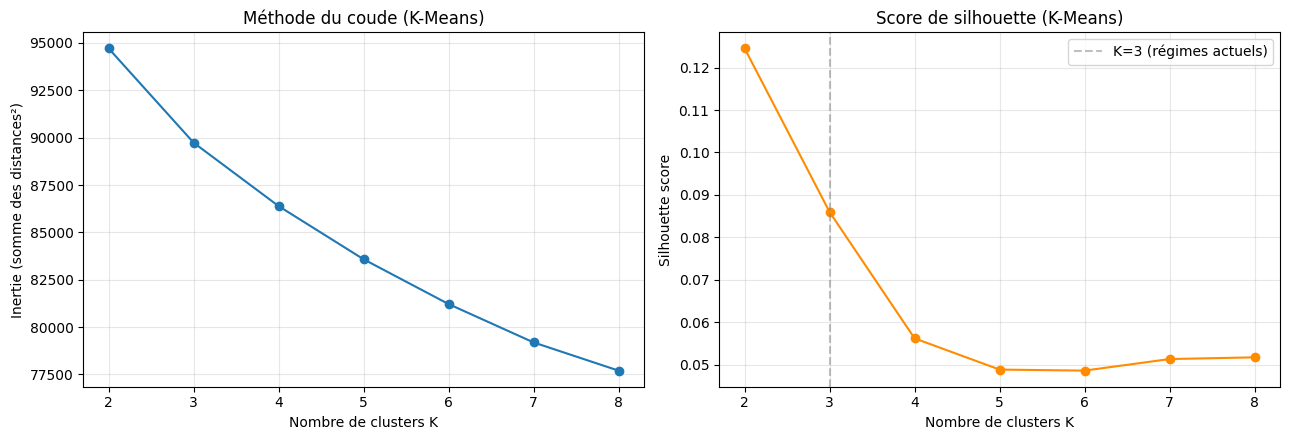


[BEST K] K=2 maximise le score de silhouette (0.1245)
[NOTE] La ligne pointillée à K=3 marque la segmentation CALM/NORMAL/STRESS actuelle, pour comparaison visuelle directe.
[GMM] K=2: BIC=271082.1, silhouette=0.1869
[GMM] K=3: BIC=239998.3, silhouette=0.0065
[GMM] K=4: BIC=210050.1, silhouette=0.0661
[GMM] K=5: BIC=211022.5, silhouette=0.0654
[GMM] K=6: BIC=210637.9, silhouette=0.0652
[GMM] K=7: BIC=210264.0, silhouette=0.0506
[GMM] K=8: BIC=210793.7, silhouette=0.0606


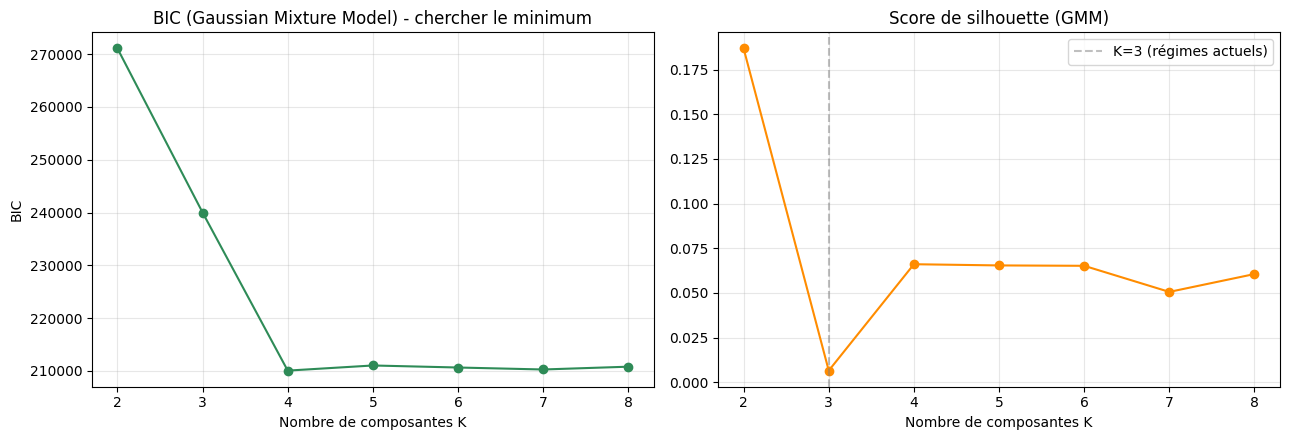


[BEST K] K=4 minimise le BIC pour GMM


In [22]:
# =============================================================================
# DÉTERMINATION DU NOMBRE OPTIMAL DE CLUSTERS
# (pas présupposé à 3 - méthode du coude + score de silhouette)
#
# - Inertie K-Means (somme des distances au carré aux centroïdes) : décroît
#   toujours avec K, on cherche le "coude" où le gain marginal ralentit.
# - Score de silhouette : mesure à quel point chaque point est bien assigné
#   à son cluster vs les clusters voisins, en [-1, 1]. Proche de 1 = clusters
#   bien séparés, proche de 0 = clusters qui se chevauchent, négatif = points
#   probablement mal assignés. On cherche le K qui MAXIMISE ce score.
# =============================================================================

kmeans_results = []
for k in K_RANGE_TO_TEST:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster.values)
    sil = silhouette_score(X_cluster.values, labels)
    kmeans_results.append({"K": k, "Inertia": km.inertia_, "Silhouette": sil})
    print(f"[K-MEANS] K={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

kmeans_k_selection_df = pd.DataFrame(kmeans_results)
kmeans_k_selection_df.to_csv(OUTPUT_DIR / "kmeans_k_selection.csv", index=False)

# --- Graphique elbow + silhouette côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(kmeans_k_selection_df["K"], kmeans_k_selection_df["Inertia"], marker="o")
axes[0].set_title("Méthode du coude (K-Means)")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("Inertie (somme des distances²)")
axes[0].grid(alpha=0.3)

axes[1].plot(kmeans_k_selection_df["K"], kmeans_k_selection_df["Silhouette"], marker="o", color="darkorange")
axes[1].axvline(3, color="grey", linestyle="--", alpha=0.5, label="K=3 (régimes actuels)")
axes[1].set_title("Score de silhouette (K-Means)")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kmeans_k_selection.png", dpi=150)
plt.show()

best_k_silhouette = int(kmeans_k_selection_df.loc[kmeans_k_selection_df["Silhouette"].idxmax(), "K"])
print(f"\n[BEST K] K={best_k_silhouette} maximise le score de silhouette "
      f"({kmeans_k_selection_df['Silhouette'].max():.4f})")
print("[NOTE] La ligne pointillée à K=3 marque la segmentation CALM/NORMAL/STRESS "
      "actuelle, pour comparaison visuelle directe.")


# --- Même exercice pour GMM, via le critère BIC (Bayesian Information Criterion) ---
# BIC pénalise la complexité du modèle (plus de composantes = plus de paramètres) -
# on cherche le K qui MINIMISE le BIC, pas qui le maximise.
gmm_results = []
for k in K_RANGE_TO_TEST:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=5)
    gmm.fit(X_cluster.values)
    bic = gmm.bic(X_cluster.values)
    labels_gmm = gmm.predict(X_cluster.values)
    sil_gmm = silhouette_score(X_cluster.values, labels_gmm) if len(set(labels_gmm)) > 1 else np.nan
    gmm_results.append({"K": k, "BIC": bic, "Silhouette": sil_gmm})
    print(f"[GMM] K={k}: BIC={bic:.1f}, silhouette={sil_gmm:.4f}")

gmm_k_selection_df = pd.DataFrame(gmm_results)
gmm_k_selection_df.to_csv(OUTPUT_DIR / "gmm_k_selection.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(gmm_k_selection_df["K"], gmm_k_selection_df["BIC"], marker="o", color="seagreen")
axes[0].set_title("BIC (Gaussian Mixture Model) - chercher le minimum")
axes[0].set_xlabel("Nombre de composantes K")
axes[0].set_ylabel("BIC")
axes[0].grid(alpha=0.3)

axes[1].plot(gmm_k_selection_df["K"], gmm_k_selection_df["Silhouette"], marker="o", color="darkorange")
axes[1].axvline(3, color="grey", linestyle="--", alpha=0.5, label="K=3 (régimes actuels)")
axes[1].set_title("Score de silhouette (GMM)")
axes[1].set_xlabel("Nombre de composantes K")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gmm_k_selection.png", dpi=150)
plt.show()

best_k_bic = int(gmm_k_selection_df.loc[gmm_k_selection_df["BIC"].idxmin(), "K"])
print(f"\n[BEST K] K={best_k_bic} minimise le BIC pour GMM")


In [23]:
# =============================================================================
# CLUSTERING FINAL avec le K choisi (par défaut : le K qui maximise le score
# de silhouette pour K-Means - modifiable manuellement ci-dessous si tu veux
# explorer un autre K après avoir vu les graphiques précédents).
# =============================================================================

K_CHOSEN = best_k_silhouette  # <-- change cette valeur pour explorer un autre K manuellement

print(f"[CLUSTERING FINAL] K={K_CHOSEN}")

kmeans_final = KMeans(n_clusters=K_CHOSEN, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_cluster.values)

gmm_final = GaussianMixture(n_components=K_CHOSEN, random_state=RANDOM_STATE, n_init=5)
gmm_labels = gmm_final.fit_predict(X_cluster.values)
gmm_proba = gmm_final.predict_proba(X_cluster.values)  # probabilité d'appartenance à chaque cluster

clusters_df = pd.DataFrame({
    "KMeans_Cluster": kmeans_labels,
    "GMM_Cluster": gmm_labels,
}, index=X_cluster.index)

# Probabilité max d'appartenance GMM (proche de 1 = assignation nette,
# proche de 1/K = jour ambigu entre plusieurs régimes)
clusters_df["GMM_Max_Proba"] = gmm_proba.max(axis=1)

# --- Comparaison avec le régime VIX existant (seuils q33/q67, calcul minimal
# autonome ici, indépendant du pipeline supervisé) ---
vix_col = "VIX_Price" if "VIX_Price" in df_clean.columns else "VIX"
vix_series = df_clean[vix_col].reindex(X_cluster.index)
calm_threshold = vix_series.quantile(0.33)
stress_threshold = vix_series.quantile(0.67)

vix_regime = pd.Series("NORMAL", index=vix_series.index)
vix_regime.loc[vix_series < calm_threshold] = "CALM"
vix_regime.loc[vix_series >= stress_threshold] = "STRESS"
clusters_df["VIX_Regime_Existing"] = vix_regime
clusters_df["VIX_Level"] = vix_series

clusters_df.to_csv(OUTPUT_DIR / "cluster_assignments.csv")
print(f"[SAVE] cluster_assignments.csv ({len(clusters_df)} lignes)")

# --- Table de contingence : clusters K-Means vs régime VIX existant ---
print("\n[CONTINGENCE] K-Means cluster vs régime VIX existant (nombre de jours) :")
contingency_kmeans = pd.crosstab(clusters_df["KMeans_Cluster"], clusters_df["VIX_Regime_Existing"])
display(contingency_kmeans)

print("\n[CONTINGENCE] GMM cluster vs régime VIX existant (nombre de jours) :")
contingency_gmm = pd.crosstab(clusters_df["GMM_Cluster"], clusters_df["VIX_Regime_Existing"])
display(contingency_gmm)

contingency_kmeans.to_csv(OUTPUT_DIR / "contingency_kmeans_vs_vix_regime.csv")
contingency_gmm.to_csv(OUTPUT_DIR / "contingency_gmm_vs_vix_regime.csv")


[CLUSTERING FINAL] K=2
[SAVE] cluster_assignments.csv (5269 lignes)

[CONTINGENCE] K-Means cluster vs régime VIX existant (nombre de jours) :


VIX_Regime_Existing,CALM,NORMAL,STRESS
KMeans_Cluster,,,
0,264,543,955
1,1474,1246,787



[CONTINGENCE] GMM cluster vs régime VIX existant (nombre de jours) :


VIX_Regime_Existing,CALM,NORMAL,STRESS
GMM_Cluster,,,
0,1650,1505,985
1,88,284,757


[PROFIL DES CLUSTERS] Moyenne de chaque feature (standardisée) par cluster K-Means :


,Oil_Price_zscore_60d,spx_down_day,FedFunds_zscore_60d,US30Y_Rate_ret_1d,US2Y_Rate_ret_5d,TAP_MolsonCoors_zscore_60d,GILD_Gilead_ret_5d,EMR_Emerson_ret_20d,SPG_SimonProperty_zscore_60d,yield_curve_change_20d,AMD_vol_20d,PCAR_PaccarInc_ret_5d,T_ret_5d,EWT_Taiwan_ret_5d,PFE_vol_20d,CCI_CrownCastle_vol_20d,EQIX_Equinix_zscore_60d,ES_Evergy_zscore_60d,LMT_LockheedMartin_ret_20d,EWI_Italy_ret_20d
KMeans_Cluster,,,,,,,,,,,,,,,,,,,,
0,-0.243,0.359,0.014,-0.131,-0.185,-0.565,-0.326,-0.699,-0.687,0.090,0.298,-0.472,-0.384,-0.494,0.341,0.299,-0.706,-0.619,-0.382,-0.679
1,0.122,-0.180,-0.007,0.066,0.093,0.284,0.164,0.351,0.345,-0.045,-0.150,0.237,0.193,0.248,-0.172,-0.150,0.355,0.311,0.192,0.341


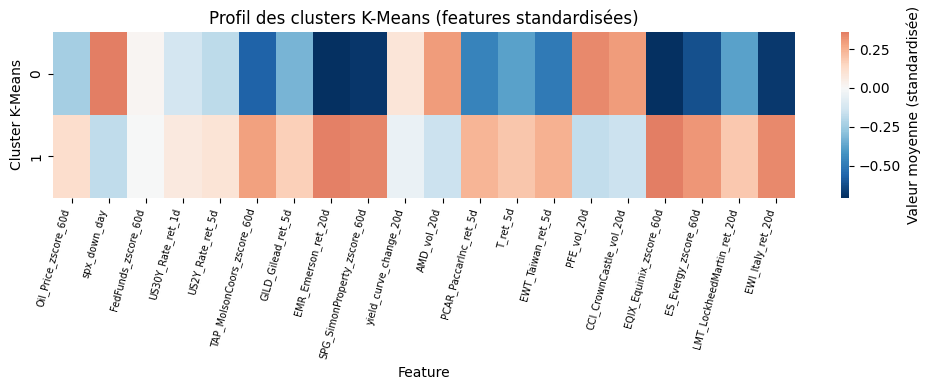


[VIX PAR CLUSTER] Niveau de VIX moyen/médian par cluster K-Means :


,mean,median,std,count
KMeans_Cluster,,,,
0,23.45,21.35,9.78,1762
1,17.08,15.89,5.49,3507



[PCA] Variance expliquée par les 2 premières composantes : 17.2% + 10.6% = 27.8% du total


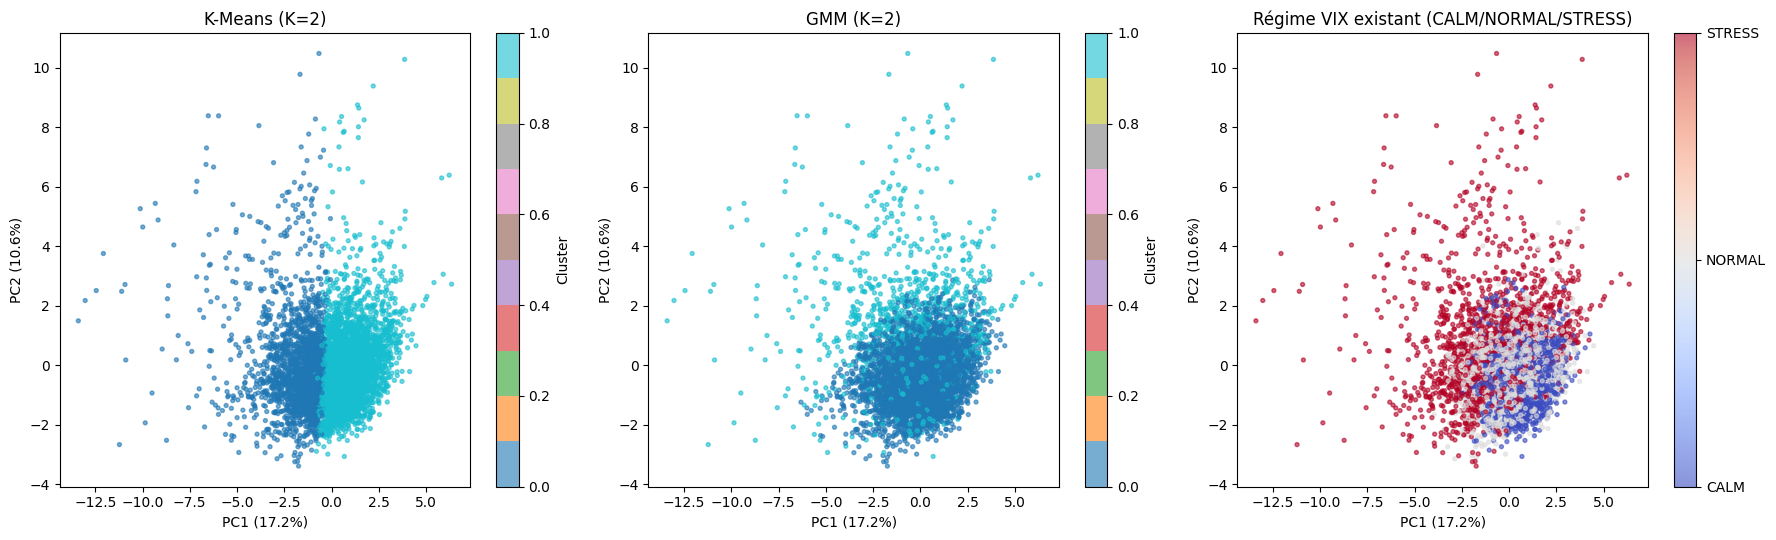


[LECTURE] Si les 3 panneaux montrent des frontières similaires, le clustering
non supervisé retrouve essentiellement la même structure que les seuils VIX.
Si les frontières diffèrent nettement, le clustering capture une dynamique de
marché plus riche que le niveau de VIX seul (ex: un cluster 'stress de crédit'
qui ne correspond pas exactement aux pics de VIX).


In [24]:
# =============================================================================
# CARACTÉRISATION DES CLUSTERS : quelles features distinguent chaque cluster ?
# Moyenne (sur données standardisées) de chaque feature, par cluster K-Means -
# permet de donner un "nom" interprétable à chaque cluster (ex: "stress de
# crédit sans pic VIX", "calme avec dollar fort", etc.) plutôt qu'un numéro.
# =============================================================================

cluster_profile = X_cluster.copy()
cluster_profile["KMeans_Cluster"] = kmeans_labels
cluster_means = cluster_profile.groupby("KMeans_Cluster")[selected_features].mean()

print("[PROFIL DES CLUSTERS] Moyenne de chaque feature (standardisée) par cluster K-Means :")
display(cluster_means.round(3))

cluster_means.to_csv(OUTPUT_DIR / "kmeans_cluster_feature_profile.csv")

# --- Heatmap du profil des clusters (lecture visuelle rapide) ---
fig, ax = plt.subplots(figsize=(max(10, len(selected_features) * 0.5), max(4, K_CHOSEN * 0.8)))
sns.heatmap(cluster_means, cmap="RdBu_r", center=0, annot=False, cbar_kws={"label": "Valeur moyenne (standardisée)"}, ax=ax)
ax.set_title("Profil des clusters K-Means (features standardisées)")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster K-Means")
plt.xticks(rotation=75, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "kmeans_cluster_heatmap.png", dpi=150)
plt.show()

# --- Niveau de VIX moyen par cluster (lecture la plus directe pour comparer
# aux régimes existants) ---
vix_by_cluster = clusters_df.groupby("KMeans_Cluster")["VIX_Level"].agg(["mean", "median", "std", "count"])
print("\n[VIX PAR CLUSTER] Niveau de VIX moyen/médian par cluster K-Means :")
display(vix_by_cluster.round(2))
vix_by_cluster.to_csv(OUTPUT_DIR / "vix_level_by_kmeans_cluster.csv")


# =============================================================================
# VISUALISATION PCA 2D : projection des clusters sur les 2 premières
# composantes principales, pour une lecture visuelle directe (impossible de
# visualiser N_FINAL_CLUSTERING_FEATURES dimensions directement).
# =============================================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster.values)
print(f"\n[PCA] Variance expliquée par les 2 premières composantes : "
      f"{pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%} "
      f"= {pca.explained_variance_ratio_.sum():.1%} du total")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="tab10", s=8, alpha=0.6)
axes[0].set_title(f"K-Means (K={K_CHOSEN})")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(scatter0, ax=axes[0], label="Cluster")

scatter1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap="tab10", s=8, alpha=0.6)
axes[1].set_title(f"GMM (K={K_CHOSEN})")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(scatter1, ax=axes[1], label="Cluster")

vix_regime_codes = clusters_df["VIX_Regime_Existing"].map({"CALM": 0, "NORMAL": 1, "STRESS": 2})
scatter2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=vix_regime_codes, cmap="coolwarm", s=8, alpha=0.6)
axes[2].set_title("Régime VIX existant (CALM/NORMAL/STRESS)")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
cbar2 = plt.colorbar(scatter2, ax=axes[2], ticks=[0, 1, 2])
cbar2.ax.set_yticklabels(["CALM", "NORMAL", "STRESS"])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_clusters_comparison.png", dpi=150)
plt.show()

print("\n[LECTURE] Si les 3 panneaux montrent des frontières similaires, le clustering")
print("non supervisé retrouve essentiellement la même structure que les seuils VIX.")
print("Si les frontières diffèrent nettement, le clustering capture une dynamique de")
print("marché plus riche que le niveau de VIX seul (ex: un cluster \'stress de crédit\'")
print("qui ne correspond pas exactement aux pics de VIX).")


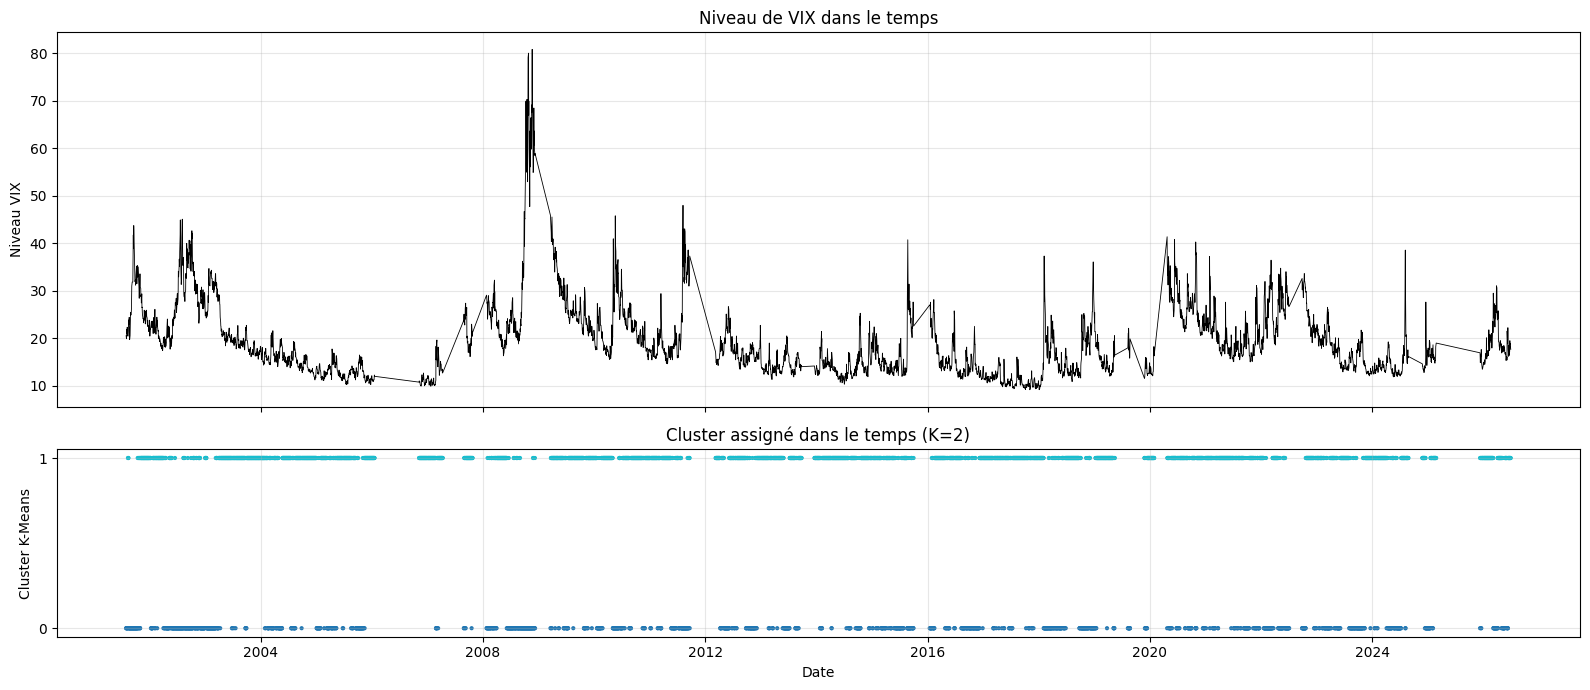

[LECTURE] Repère les périodes de crise connues (GFC 2008, flash crash 2010,
dégradation US 2011, Volmageddon 2018, COVID 2020, resserrement Fed 2022) sur
le graphique du haut, et vérifie si elles correspondent à un cluster distinct
et cohérent dans le graphique du bas - signe que le clustering capture une
vraie dynamique de marché plutôt que du bruit statistique.

RÉCAPITULATIF DES FICHIERS GÉNÉRÉS
  - /content/outputs_v21_regime_clustering_exploration/clustering_selected_features.csv
  - /content/outputs_v21_regime_clustering_exploration/kmeans_k_selection.csv + .png
  - /content/outputs_v21_regime_clustering_exploration/gmm_k_selection.csv + .png
  - /content/outputs_v21_regime_clustering_exploration/cluster_assignments.csv (K-Means + GMM + régime VIX existant, par jour)
  - /content/outputs_v21_regime_clustering_exploration/contingency_kmeans_vs_vix_regime.csv
  - /content/outputs_v21_regime_clustering_exploration/contingency_gmm_vs_vix_regime.csv
  - /content/outputs_v21_regime_clu

In [25]:
# =============================================================================
# TIMELINE : évolution du cluster K-Means assigné dans le temps, superposée
# au niveau de VIX - pour vérifier si les clusters correspondent à des
# périodes historiques reconnaissables (GFC 2008, COVID 2020, etc.) plutôt
# qu'à un découpage arbitraire du nuage de points.
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(clusters_df.index, clusters_df["VIX_Level"], color="black", linewidth=0.6)
axes[0].set_ylabel("Niveau VIX")
axes[0].set_title("Niveau de VIX dans le temps")
axes[0].grid(alpha=0.3)

scatter_timeline = axes[1].scatter(
    clusters_df.index, clusters_df["KMeans_Cluster"],
    c=clusters_df["KMeans_Cluster"], cmap="tab10", s=4
)
axes[1].set_ylabel("Cluster K-Means")
axes[1].set_xlabel("Date")
axes[1].set_title(f"Cluster assigné dans le temps (K={K_CHOSEN})")
axes[1].set_yticks(range(K_CHOSEN))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_timeline.png", dpi=150)
plt.show()

print("[LECTURE] Repère les périodes de crise connues (GFC 2008, flash crash 2010,")
print("dégradation US 2011, Volmageddon 2018, COVID 2020, resserrement Fed 2022) sur")
print("le graphique du haut, et vérifie si elles correspondent à un cluster distinct")
print("et cohérent dans le graphique du bas - signe que le clustering capture une")
print("vraie dynamique de marché plutôt que du bruit statistique.")

print("\n" + "="*80)
print("RÉCAPITULATIF DES FICHIERS GÉNÉRÉS")
print("="*80)
print(f"  - {OUTPUT_DIR}/clustering_selected_features.csv")
print(f"  - {OUTPUT_DIR}/kmeans_k_selection.csv + .png")
print(f"  - {OUTPUT_DIR}/gmm_k_selection.csv + .png")
print(f"  - {OUTPUT_DIR}/cluster_assignments.csv (K-Means + GMM + régime VIX existant, par jour)")
print(f"  - {OUTPUT_DIR}/contingency_kmeans_vs_vix_regime.csv")
print(f"  - {OUTPUT_DIR}/contingency_gmm_vs_vix_regime.csv")
print(f"  - {OUTPUT_DIR}/kmeans_cluster_feature_profile.csv + heatmap .png")
print(f"  - {OUTPUT_DIR}/vix_level_by_kmeans_cluster.csv")
print(f"  - {OUTPUT_DIR}/pca_clusters_comparison.png")
print(f"  - {OUTPUT_DIR}/cluster_timeline.png")
print("\n[RAPPEL] Aucun modèle prédictif n\'a été entraîné dans ce notebook.")
print("C\'est un outil d\'exploration : si les clusters semblent intéressants et")
print("économiquement interprétables, l\'étape suivante serait de les tester comme")
print("nouvelle définition de régime dans le pipeline supervisé existant.")
